### Open in Google Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/koffifidelek59/hr-attrition-analysis/blob/main/Task3_HR_Analysis.ipynb)

Run every cell from the top. When the notebook asks for the dataset, upload it with
the file picker that appears. The last cell downloads all outputs back to your
machine.

# Employee Data Analysis: Performance, Pay, Satisfaction and Attrition
### IBM HR Employee Attrition, 1,470 employees

---

## Authors

**KOUAME Koffi Fidèle**
Data Analysis Internship

## Contact info

koffifidelek59@gmail.com

## Overview

A company loses roughly one employee in six each year and wants to know why. This
notebook takes an HR extract of 1,470 employee records, establishes what the file
can and cannot support, and identifies which factors actually separate the people
who leave from the people who stay.

Every code cell is preceded by a table stating its **input**, the **method** it
applies and the **output** it produces, and every concept is defined at the point
where it is first used.

## What this analysis found

**Attrition is 16.1% company-wide, and that number is almost useless on its own.**
It ranges from 7.3% to 67.8% depending on which three questions you ask about an
employee.

Four findings, in order of how much they should change what the company does:

1. **Overtime is the strongest single predictor**, 30.5% against 10.4%, and it is
   the only strong factor the company directly controls. The others are attributes
   of the employee.
2. **Risk factors compound rather than add.** 59 employees who work overtime, sit
   at job level 1 and are single leave at **67.8%**, more than four times the
   company rate.
3. **The first two years hold 23% of staff and 43% of all departures.** This is an
   onboarding problem, not a company-wide retention problem.
4. **The performance dimension the brief asks about cannot be analysed.** The
   rating scale contains only the values 3 and 4: no employee in 1,470 is rated
   below 3. That is a finding about the company's appraisal process, and it is
   reported rather than worked around.

## Study Goals

By the end of this notebook you will be able to:

1. **Diagnose** an HR extract that has no missing values and no duplicates, and
   still find three defects that would corrupt a conclusion.
2. **Recognise a censored scale** and understand why it invalidates every analysis
   built on it.
3. **Express segment risk as a lift** rather than a raw rate, and explain why a
   rate on its own is not comparable between segments.
4. **Show that risk factors compound**, and turn that into a named population an
   HR team can act on this quarter.
5. **State what the data cannot answer**, which on this file is as important as
   what it can.

## Table of Contents

1. [Understanding the task](#task)
2. [Business impact](#impact)
3. [Target audience](#audience)
4. [Background and prerequisites](#background)
5. [Software requirements](#software)
6. [Data description and datasheet](#datasheet)
7. [Data download](#download)
8. [Diagnosis](#diagnosis)
9. [Cleaning](#cleaning)
10. [Validation](#validation)
11. [Analysis](#analysis)
12. [Charts](#charts)
13. [Insights and recommendations](#insights)
14. [Limitations](#limits)
15. [References](#refs)

<a id="task"></a>
# 1. Understanding the task

## What is being asked

Clean the data, analyse employees by department and job role, analyse pay,
experience and performance, analyse satisfaction, analyse attrition and its
related factors, visualise, and build an interactive dashboard.

## The vocabulary used throughout

| Term | Definition |
| :--- | :--- |
| **Attrition** | An employee who has left. In this file it is a yes or no flag with **no leaving date**, which bounds everything that can be said about trend |
| **Attrition rate** | Leavers divided by headcount, within a segment |
| **Lift** | A segment's attrition rate divided by the company rate. A lift of 2.0 means the segment leaves twice as often as the company average |
| **Ordinal scale** | A coded rank, 1 to 4 here, where 4 is better than 3 but the distance between them is not a quantity |
| **Censored scale** | A scale on which part of the range never occurs. `PerformanceRating` is censored below 3 |
| **Constant column** | A column holding the same value on every row. It cannot explain any difference between employees |
| **Compounding risk** | Two risk factors whose combined effect exceeds the sum of their separate effects |

## Why lift rather than rate

A rate on its own is not comparable. Twenty per cent attrition is alarming in one
company and unremarkable in another, and a segment at 20% means something
different depending on whether the company sits at 5% or at 30%.

$$\text{lift} = \frac{\text{attrition rate in the segment}}{\text{attrition rate in the company}}$$

A lift above 1 means the segment leaves more often than average, below 1 less
often. Every ranking in this notebook uses it.

<a id="impact"></a>
# 2. Business impact

Replacing an employee costs a substantial multiple of their salary: recruitment,
the vacancy, and the months before a replacement is productive. At 16.1% on 1,470
employees that is roughly 237 replacements a year.

Three decisions depend on what follows.

**Where to spend the retention budget.** A general engagement programme spends most
of its money on people who were never going to leave. This notebook identifies a
group of 59 employees leaving at 67.8% and a group of 667 leaving at 7.3%.

**Whether to raise pay.** The data says pay matters at the bottom of the scale and
almost nowhere else. A general rise would be expensive and largely ineffective.

**Whether the company can measure performance at all.** It currently cannot, and
that is a governance finding rather than an analytical one.

<a id="audience"></a>
# 3. Target audience

- **HR business partners** who need to know which employees to talk to this quarter.
- **Data analysts** who need a worked example of an audit on a file that passes
  every routine check and is still not ready to analyse.
- **Managers** receiving an attrition dashboard, who need to know which questions
  to ask of it.

<a id="background"></a>
# 4. Background and prerequisites

**Assumed knowledge.** Intermediate Python with pandas, grouping and aggregation.
No HR background is required.

## Recommended reading

| Resource | Why | Link |
| :--- | :--- | :--- |
| McKinney, *Python for Data Analysis* (3rd ed.) | The reference for the pandas operations used here. Free online | https://wesmckinney.com/book/ |
| Gebru et al., *Datasheets for Datasets* | The convention followed in Section 6 | https://doi.org/10.1145/3458723 |
| Stevens (1946), *On the Theory of Scales of Measurement* | Why an ordinal code must not be averaged as a quantity | https://doi.org/10.1126/science.103.2684.677 |
| Cascio & Boudreau, *Investing in People* | How attrition cost is actually computed | Pearson, 2011 |

## Video resources

| Resource | Content | Link |
| :--- | :--- | :--- |
| Data School, *Data cleaning with pandas* | The operations of Section 9, demonstrated | https://www.youtube.com/watch?v=KdmPHEnPJPs |
| Storytelling with Data, *Chart selection* | Choosing a chart type from the data type | https://www.youtube.com/watch?v=8EMW7io4rSI |

## The dataset

IBM HR Analytics Employee Attrition and Performance, a widely used public dataset.
https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

<a id="software"></a>
# 5. Software requirements

#### Cell 1. Install dependencies

| | |
| :--- | :--- |
| **Input** | None. |
| **Method** | Installs pandas, NumPy, Matplotlib and Seaborn. Already present in Colab; listed so the environment is reproducible elsewhere. |
| **Output** | None. `%%capture` suppresses the installer log. |


In [1]:
%%capture
!pip install -q pandas numpy matplotlib seaborn

#### Cell 2. Imports and plotting style

| | |
| :--- | :--- |
| **Input** | None. |
| **Method** | Imports the libraries and fixes the figure style once, so every chart is consistent. |
| **Output** | A confirmation, and the `charts/` folder. |

**On the palette.** One blue scale, with amber reserved for the value that needs attention. A categorical rainbow would imply the segments differ in kind, when here they differ only in magnitude. The grid is drawn behind the bars, otherwise grid lines cross them and leave white stripes that read as missing data.


In [2]:
%matplotlib inline
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ---------------------------------------------------------------- house style
# One blue scale. Dark blue marks the value to look at first, lighter blues carry
# context, amber is reserved for the value that needs attention. A categorical
# rainbow would imply the groups differ in kind, when here they differ only in
# magnitude. The grid is drawn behind the bars, otherwise grid lines cross them
# and leave white stripes that read as missing data.
NAVY, BLUE, MID, LIGHT, PALE = "#12395E", "#1F6FB2", "#6BAED6", "#9ECAE1", "#DEEBF7"
AMBER, TEAL = "#E08A1E", "#17A2A2"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 180, "figure.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.labelsize": 11, "axes.edgecolor": "#3A3A3A", "axes.linewidth": 0.9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#E3E8ED", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10})
sns.set_palette([BLUE, MID, LIGHT, NAVY])
F = {}   # every figure quoted downstream

<a id="datasheet"></a>
# 6. Data description and datasheet

Following the convention of Gebru et al. (2021).

### Motivation
A synthetic HR dataset created by IBM data scientists to demonstrate attrition
analysis. It is synthetic, which matters: the relationships in it are plausible
and were generated, so a finding here is a finding about the dataset unless it is
confirmed on real data.

### Composition
1,470 employee records across 35 columns: demographics, job and department,
compensation, tenure and history, four satisfaction scales, and a binary attrition
flag.

### Collection process
Generated, not collected. There is no sampling frame and no response rate.

### Preprocessing applied here
Three constant columns dropped, six ordinal scales labelled, types set, and six
analysis fields derived. **No row is removed.**

### Uses
Appropriate for attrition segmentation, satisfaction analysis and pay analysis.
**Not** appropriate for performance analysis, for the reason established in
Section 8, or for any trend over time.

### Limitations and gaps
Four, in order of consequence: the performance scale is censored; three pay columns
are unrelated to pay; there is no leaving date; and there is no manager identifier,
so the overtime finding cannot be traced to the teams producing it.

<a id="download"></a>
# 7. Data download

#### Cell 3. Locate the data file

| | |
| :--- | :--- |
| **Input** | Nothing. |
| **Method** | Searches the working directory, `/content` and a mounted Drive. If none holds the file and we are in Colab, it opens the upload picker. |
| **Output** | `CSV_PATH`, plus the `data/`, `results/` and `charts/` folders. |

**Why this matters in Colab.** A notebook that hard-codes a local path runs on the author's machine and nowhere else.


In [3]:
# --- Locate the data file, wherever this notebook is running -----------------
# INPUT  : nothing. The function searches, then falls back to an upload prompt.
# METHOD : three attempts, in order of convenience: a file beside the notebook,
#          a file in Colab session storage or a mounted Drive, then an
#          interactive upload.
# OUTPUT : CSV_PATH, a path pandas can open, plus the output folders.
import os, sys

FILENAME = "HR_Attrition.csv"
IN_COLAB = "google.colab" in sys.modules
CANDIDATES = [FILENAME, f"data/{FILENAME}", f"/content/{FILENAME}",
              "WA_Fn-UseC_-HR-Employee-Attrition.csv",
              "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv",
              f"/content/drive/MyDrive/{FILENAME}"]
CSV_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)

if CSV_PATH is None and IN_COLAB:
    print("Dataset not found in this session. Please upload it now.")
    from google.colab import files
    up = files.upload()
    CSV_PATH = next(iter(up))

if CSV_PATH is None:
    raise FileNotFoundError(
        "The HR attrition CSV was not found. Place it beside this notebook, or in "
        "Colab upload it when prompted, or mount your Drive with:\n"
        "    from google.colab import drive; drive.mount('/content/drive')")

print(f"Running in Colab : {IN_COLAB}")
print(f"Data file        : {CSV_PATH}")

# Colab starts with an empty filesystem, so the output folders are created here
# rather than assumed to exist.
for folder in ["data", "results", "charts"]:
    os.makedirs(folder, exist_ok=True)

Running in Colab : False
Data file        : HR_Attrition.csv


#### Cell 4. Load the file

| | |
| :--- | :--- |
| **Input** | `CSV_PATH`. |
| **Method** | `pd.read_csv`, then a working copy. The original `raw` is kept so Section 8 can diagnose the file as supplied. |
| **Output** | `raw` and `df`, 1,470 rows by 35 columns. |


In [4]:
# =============================================================================
# 1. LOAD
# -----------------------------------------------------------------------------
# INPUT  : HR_Attrition.csv, the file as supplied
# METHOD : read once, keep the original for the duplicate check in section 2
# OUTPUT : raw and df
# =============================================================================
raw = pd.read_csv(CSV_PATH)
df = raw.copy()
F["rows"], F["cols_raw"] = len(df), df.shape[1]
print(f"Loaded {len(df):,} employee records, {df.shape[1]} columns")

Loaded 1,470 employee records, 35 columns


<a id="diagnosis"></a>
# 8. Diagnosis, before anything is changed

Nothing is modified in this section. Diagnosing after correcting reports the wrong
counts.

The routine checks will all pass: no missing values, no duplicates. That is exactly
why this section then looks for two things a routine check does not: **columns that
carry no information**, and **a scale whose range never occurs**.

#### Cell 5. Diagnose

| | |
| :--- | :--- |
| **Input** | `df` as supplied. |
| **Method** | Counts missing values and duplicates, searches for constant columns, and inspects the distribution of `PerformanceRating`. |
| **Output** | The diagnosis block of `F`. |

**The censored scale is the finding of this section.** `PerformanceRating` is documented as running from 1 to 4 and contains only 3 and 4. A column can be complete, valid and unusable at the same time, and no completeness check will say so.


In [5]:
# =============================================================================
# 2. DIAGNOSIS, before anything is changed
# -----------------------------------------------------------------------------
# INPUT  : df
# METHOD : missing values, duplicates, and a search for columns that carry no
#          information at all
# OUTPUT : the diagnosis block of F
#
# Term. A CONSTANT COLUMN holds the same value on every row. It cannot explain
# any difference between employees, so it adds width to the table and nothing to
# the analysis. Finding these is part of cleaning, not an optimisation.
# =============================================================================
F["missing_total"] = int(df.isna().sum().sum())
F["dup_full"] = int(df.duplicated().sum())
F["dup_id"] = int(df["EmployeeNumber"].duplicated().sum())
CONSTANT = [c for c in df.columns if df[c].nunique() == 1]
F["constant_cols"] = {c: str(df[c].iloc[0]) for c in CONSTANT}
print(f"\nMissing values      : {F['missing_total']}")
print(f"Duplicate rows      : {F['dup_full']}")
print(f"Duplicate employee id: {F['dup_id']}")
print(f"Constant columns    : {F['constant_cols']}")

# The censored performance scale. This is the second structural defect and the
# one a routine audit misses, because the column looks perfectly valid.
F["perf_values"] = sorted(int(v) for v in df.PerformanceRating.unique())
F["perf_counts"] = {int(k): int(v) for k, v in df.PerformanceRating.value_counts().items()}
F["perf_income_corr"] = round(float(df.PerformanceRating.corr(df.MonthlyIncome)), 3)
print(f"\nPerformanceRating values present: {F['perf_values']}")
print("  No employee is rated below 3. The scale is censored at the bottom, so")
print("  it cannot separate a strong performer from a weak one.")


Missing values      : 0
Duplicate rows      : 0
Duplicate employee id: 0
Constant columns    : {'EmployeeCount': '1', 'Over18': 'Y', 'StandardHours': '80'}

PerformanceRating values present: [3, 4]
  No employee is rated below 3. The scale is censored at the bottom, so
  it cannot separate a strong performer from a weak one.


<a id="cleaning"></a>
# 9. Cleaning

Three operations, each with its reason.

| Operation | Reason |
| :--- | :--- |
| Drop the constant columns | A column with one distinct value cannot explain any difference between employees |
| Label the ordinal scales | Stored as bare integers they invite an average that means nothing, since the distance between "Medium" and "High" is not a quantity |
| Derive the analysis fields | Bands and flags used by every chart, computed once so no chart can define them differently |

#### Cell 6. Clean and label

| | |
| :--- | :--- |
| **Input** | `df`, 35 columns with bare ordinal codes. |
| **Method** | Drops the three constant columns, adds a labelled twin for each of the six ordinal scales, sets the categorical types, and derives the attrition flag, the tenure and income bands, and the composite satisfaction score. |
| **Output** | A cleaned `df` and `data/HR_Attrition_clean.csv`. |

**On the composite score.** It is the mean of the four satisfaction scales and is used **only to band employees**, never reported as a quantity. Averaging ordinal codes is defensible for ranking and not for measurement.


In [6]:
# =============================================================================
# 3. CLEANING
# -----------------------------------------------------------------------------
# INPUT  : df, 35 columns with ordinal scales stored as bare integers
# METHOD : drop the constant columns, label the ordinal scales, set the types,
#          and derive the analysis fields
# OUTPUT : a cleaned df and data/HR_Attrition_clean.csv
#
# Term. An ORDINAL SCALE is a coded rank: 1 to 4 here, where 4 is better than 3
# but the distance between them is not a quantity. Stored as a bare integer it
# invites an average that means nothing. Labelling it makes every chart readable
# without a codebook and stops the mean being taken by accident.
# =============================================================================
df = df.drop(columns=CONSTANT)
print(f"\nDropped {len(CONSTANT)} constant columns, {df.shape[1]} remain")

SCALE4 = {1: "1 Low", 2: "2 Medium", 3: "3 High", 4: "4 Very High"}
WLB    = {1: "1 Bad", 2: "2 Good", 3: "3 Better", 4: "4 Best"}
EDU    = {1: "1 Below College", 2: "2 College", 3: "3 Bachelor",
          4: "4 Master", 5: "5 Doctor"}
LABELS = {"JobSatisfaction": SCALE4, "EnvironmentSatisfaction": SCALE4,
          "RelationshipSatisfaction": SCALE4, "JobInvolvement": SCALE4,
          "WorkLifeBalance": WLB, "Education": EDU}
for col, mapping in LABELS.items():
    df[col + "_label"] = df[col].map(mapping).astype("category")

for c in df.select_dtypes(include="str").columns:
    df[c] = df[c].astype("string").str.strip()
for c in ["Attrition", "BusinessTravel", "Department", "EducationField",
          "Gender", "JobRole", "MaritalStatus", "OverTime"]:
    df[c] = df[c].astype("category")

# Derived fields used throughout.
df["attrition_flag"] = (df.Attrition == "Yes").astype(int)
df["tenure_band"] = pd.cut(df.YearsAtCompany, [-1, 1, 2, 5, 10, 100],
                           labels=["Under 1 year", "1 to 2", "3 to 5",
                                   "6 to 10", "Over 10"])
df["income_quartile"] = pd.qcut(df.MonthlyIncome, 4,
                                labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"])
df["age_band"] = pd.cut(df.Age, [17, 25, 35, 45, 60],
                        labels=["18 to 25", "26 to 35", "36 to 45", "46 to 60"])

# A COMPOSITE SATISFACTION SCORE: the mean of the four satisfaction scales. It is
# used only to band employees, never reported as a quantity, because averaging
# ordinal codes is defensible for ranking and not for measurement.
SAT = ["JobSatisfaction", "EnvironmentSatisfaction",
       "RelationshipSatisfaction", "WorkLifeBalance"]
df["satisfaction_mean"] = df[SAT].mean(axis=1)
df["satisfaction_band"] = pd.cut(df.satisfaction_mean, [0, 2, 2.75, 3.5, 4],
                                 labels=["Low", "Below average", "Good", "High"])

os.makedirs("data", exist_ok=True)
df.to_csv("data/HR_Attrition_clean.csv", index=False)
F["cols_clean"] = df.shape[1]
print(f"Clean table written: {len(df):,} rows x {df.shape[1]} columns")


Dropped 3 constant columns, 32 remain
Clean table written: 1,470 rows x 44 columns


<a id="validation"></a>
# 10. Validation

## What validation means here

Not a second look at the summary statistics. A set of statements that **must** be
true if the records are internally consistent, tested one at a time.

Years at the company cannot exceed total working years. A promotion cannot predate
the hire. A career cannot start before age 16. A breach of any of these is a defect,
never a business event.

The section then tests something the column names actively hide: whether the three
rate columns have anything to do with pay.

#### Cell 7. Validate

| | |
| :--- | :--- |
| **Input** | The cleaned `df`. |
| **Method** | Eight internal consistency rules, then the correlation between each rate column and actual monthly income. |
| **Output** | The validation block of `F`, written to `results/findings.json`. |

**The rate columns are the finding here.** `HourlyRate`, `DailyRate` and `MonthlyRate` look like compensation. Their correlation with `MonthlyIncome` is below 0.04 in absolute value. An analyst who takes them at face value produces a pay analysis that is entirely noise, and nothing in the column name warns them.


In [7]:
# =============================================================================
# 4. VALIDATION
# -----------------------------------------------------------------------------
# INPUT  : the cleaned df
# METHOD : eight rules that must hold if the records are internally consistent
# OUTPUT : the validation block of F
#
# Term. An INTERNAL CONSISTENCY RULE relates two fields that cannot contradict
# each other. Years at the company cannot exceed total working years; a promotion
# cannot predate the hire. A breach is a defect, never a business event.
# =============================================================================
V = {
 "years_at_company_gt_total": int((df.YearsAtCompany > df.TotalWorkingYears).sum()),
 "years_in_role_gt_at_company": int((df.YearsInCurrentRole > df.YearsAtCompany).sum()),
 "years_with_manager_gt_at_company": int((df.YearsWithCurrManager > df.YearsAtCompany).sum()),
 "promotion_gt_at_company": int((df.YearsSinceLastPromotion > df.YearsAtCompany).sum()),
 "age_minus_working_years_lt_16": int(((df.Age - df.TotalWorkingYears) < 16).sum()),
 "income_le_0": int((df.MonthlyIncome <= 0).sum()),
 "rate_inconsistent": int((df.MonthlyRate < df.DailyRate).sum()),
 "satisfaction_out_of_range": int((~df[SAT].isin([1, 2, 3, 4]).all(axis=1)).sum()),
}
F["validation"] = V
print("\nINTERNAL CONSISTENCY")
for k, n in V.items():
    print(f"  {k:<34} {n:>5}")
print("\n  MonthlyRate and DailyRate are unrelated to MonthlyIncome in this file:")
for c in ["MonthlyRate", "DailyRate", "HourlyRate"]:
    F[f"corr_income_{c}"] = round(float(df.MonthlyIncome.corr(df[c])), 3)
    print(f"    corr(MonthlyIncome, {c:<12}) = {F[f'corr_income_{c}']:+.3f}")
print("  They are synthetic filler and are excluded from every pay analysis.")
json.dump(F, open("results/findings.json", "w"), indent=2, default=str)


INTERNAL CONSISTENCY
  years_at_company_gt_total              0
  years_in_role_gt_at_company            0
  years_with_manager_gt_at_company       0
  promotion_gt_at_company                0
  age_minus_working_years_lt_16          0
  income_le_0                            0
  rate_inconsistent                      0
  satisfaction_out_of_range              0

  MonthlyRate and DailyRate are unrelated to MonthlyIncome in this file:
    corr(MonthlyIncome, MonthlyRate ) = +0.035
    corr(MonthlyIncome, DailyRate   ) = +0.008
    corr(MonthlyIncome, HourlyRate  ) = -0.016
  They are synthetic filler and are excluded from every pay analysis.


<a id="analysis"></a>
# 11. Analysis

## Method

Every figure is an attrition rate within a segment, expressed as a **lift** against
the company baseline, with the headcount reported beside it so a rate computed on
twelve people is never mistaken for a finding.

Segments below 20 employees are excluded from the ranked tables. A 50% rate on four
people is not a signal.

#### Cell 8. Segment and rank

| | |
| :--- | :--- |
| **Input** | The validated `df`. |
| **Method** | Attrition rate, headcount and lift for fifteen segmenting columns, then the compound risk group and the early-tenure concentration. |
| **Output** | Fifteen tables in `results/`, and every figure quoted in the report. |

**The compound group is the operational result.** Each factor alone is a moderate risk. Overtime, job level 1 and single together produce a rate of 67.8% on 59 named individuals, which is a list an HR team can work through this quarter.


In [8]:
# =============================================================================
# 5. ANALYSIS
# -----------------------------------------------------------------------------
# INPUT  : the validated df
# METHOD : the attrition rate within every segment, expressed as a LIFT against
#          the company baseline
# OUTPUT : the aggregate tables in results/ and the findings block of F
#
# Term. LIFT is the attrition rate of a group divided by the company rate. A lift
# of 2.0 means the group leaves twice as often as the company average. A rate on
# its own is not actionable, because 20% is alarming in one company and normal in
# another; a lift is comparable across segments and is what makes the ranking
# below meaningful.
# =============================================================================
BASE = df.attrition_flag.mean()
F["headcount"] = int(len(df))
F["leavers"] = int(df.attrition_flag.sum())
F["attrition_rate"] = round(100 * BASE, 1)
F["avg_income"] = float(df.MonthlyIncome.mean())
F["median_income"] = float(df.MonthlyIncome.median())
F["avg_tenure"] = round(float(df.YearsAtCompany.mean()), 1)
F["avg_age"] = round(float(df.Age.mean()), 1)
F["departments"] = int(df.Department.nunique())
F["job_roles"] = int(df.JobRole.nunique())
F["overtime_share"] = round(100 * (df.OverTime == "Yes").mean(), 1)

def by(col, min_n=20):
    """Attrition rate, headcount and lift for one segmenting column."""
    g = (df.groupby(col, observed=True)
           .agg(headcount=("attrition_flag", "size"),
                leavers=("attrition_flag", "sum"),
                rate=("attrition_flag", "mean"),
                median_income=("MonthlyIncome", "median")))
    g["attrition_pct"] = (100 * g.rate).round(1)
    g["lift"] = (g.rate / BASE).round(2)
    return g[g.headcount >= min_n].sort_values("rate", ascending=False)

TABLES = {}
for col in ["Department", "JobRole", "OverTime", "MaritalStatus", "BusinessTravel",
            "JobLevel", "StockOptionLevel", "Gender", "tenure_band",
            "income_quartile", "satisfaction_band", "age_band",
            "JobSatisfaction_label", "WorkLifeBalance_label",
            "EnvironmentSatisfaction_label"]:
    t = by(col)
    TABLES[col] = t
    t.drop(columns="rate").to_csv(f"results/attrition_by_{col}.csv")

print(f"\nBaseline attrition {F['attrition_rate']}%  "
      f"({F['leavers']} leavers of {F['headcount']} employees)\n")
for col in ["OverTime", "JobRole", "JobLevel", "tenure_band", "income_quartile"]:
    print(f"--- {col} ---")
    print(TABLES[col][["headcount", "attrition_pct", "lift"]].to_string())
    print()

# The compounding effect. Each factor alone is a moderate risk; together they are
# not additive, and that is the operational point.
risk = (df.OverTime == "Yes") & (df.JobLevel == 1) & (df.MaritalStatus == "Single")
safe = (df.OverTime == "No") & (df.JobLevel >= 2)
F["risk_n"] = int(risk.sum())
F["risk_rate"] = round(100 * df.loc[risk, "attrition_flag"].mean(), 1)
F["risk_lift"] = round(df.loc[risk, "attrition_flag"].mean() / BASE, 2)
F["safe_n"] = int(safe.sum())
F["safe_rate"] = round(100 * df.loc[safe, "attrition_flag"].mean(), 1)

early = df[df.YearsAtCompany <= 2]
F["early_n"] = int(len(early))
F["early_staff_share"] = round(100 * len(early) / len(df), 1)
F["early_leaver_share"] = round(100 * early.attrition_flag.sum() / df.attrition_flag.sum(), 1)
F["first_year_rate"] = round(100 * df.loc[df.YearsAtCompany <= 1, "attrition_flag"].mean(), 1)

F["overtime_rate"] = round(100 * df.loc[df.OverTime == "Yes", "attrition_flag"].mean(), 1)
F["no_overtime_rate"] = round(100 * df.loc[df.OverTime == "No", "attrition_flag"].mean(), 1)
F["overtime_lift"] = round(F["overtime_rate"] / F["no_overtime_rate"], 2)
F["income_q1_rate"] = float(TABLES["income_quartile"].loc["Q1 lowest", "attrition_pct"])
F["income_q4_rate"] = float(TABLES["income_quartile"].loc["Q4 highest", "attrition_pct"])
F["median_income_stayed"] = float(df.loc[df.attrition_flag == 0, "MonthlyIncome"].median())
F["median_income_left"] = float(df.loc[df.attrition_flag == 1, "MonthlyIncome"].median())
F["top_role"] = str(TABLES["JobRole"].index[0])
F["top_role_rate"] = float(TABLES["JobRole"].iloc[0]["attrition_pct"])
F["top_role_lift"] = float(TABLES["JobRole"].iloc[0]["lift"])

print(f"Overtime            : {F['overtime_rate']}% against {F['no_overtime_rate']}%"
      f"  ({F['overtime_lift']}x)")
print(f"Compound risk group : n={F['risk_n']}, {F['risk_rate']}% leave "
      f"({F['risk_lift']}x baseline)")
print(f"Protected group     : n={F['safe_n']}, {F['safe_rate']}% leave")
print(f"First two years     : {F['early_staff_share']}% of staff, "
      f"{F['early_leaver_share']}% of all departures")
json.dump(F, open("results/findings.json", "w"), indent=2, default=str)


Baseline attrition 16.1%  (237 leavers of 1470 employees)

--- OverTime ---
          headcount  attrition_pct  lift
OverTime                                
Yes             416           30.5  1.89
No             1054           10.4  0.65

--- JobRole ---
                           headcount  attrition_pct  lift
JobRole                                                  
Sales Representative              83           39.8  2.47
Laboratory Technician            259           23.9  1.48
Human Resources                   52           23.1  1.43
Sales Executive                  326           17.5  1.08
Research Scientist               292           16.1  1.00
Manufacturing Director           145            6.9  0.43
Healthcare Representative        131            6.9  0.43
Manager                          102            4.9  0.30
Research Director                 80            2.5  0.16

--- JobLevel ---
          headcount  attrition_pct  lift
JobLevel                                
1   

<a id="charts"></a>
# 12. Charts

## Choosing the chart type from the data type

| Figure | Data type | Type chosen | Why |
| :--- | :--- | :--- | :--- |
| 1. Job role | Nominal, long labels | Horizontal bars | Labels read without rotation |
| 2. Four factors | Nominal, four panels | Horizontal bars, shared scale | A shared scale is what makes the panels comparable |
| 3. Tenure | Ordered progression | Line | A line shows a trajectory; bars would suggest independent categories |
| 4. Pay | Continuous and banded | Histogram plus bars | The distribution and the rate say different things, and neither alone is enough |
| 5. Satisfaction | Ordinal | Grouped bars | Puts the three scales on one axis so their gradients can be compared |
| 6. Compounding | Nested segments | Horizontal bars | The point is the progression from 16% to 68%, which reads left to right |

**Every rate chart carries the company baseline as a dashed line.** A rate without
its reference is not interpretable.

#### Cell 9. Draw the six figures

| | |
| :--- | :--- |
| **Input** | The tables from Section 11. |
| **Method** | Six figures in the blue scale, with amber marking any segment at 1.5 times the company rate or above, and the baseline drawn on every panel. |
| **Output** | Six PNG files in `charts/`, displayed inline below each call. |


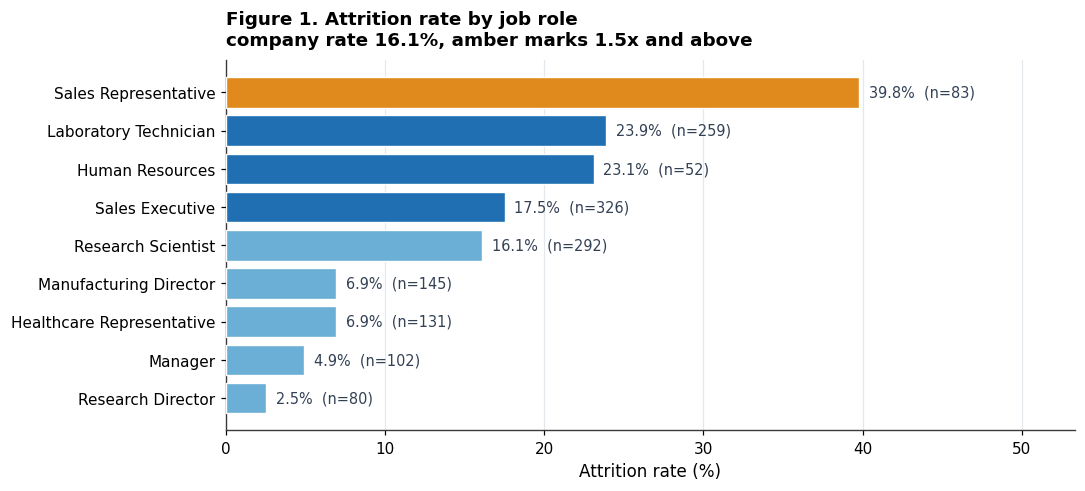

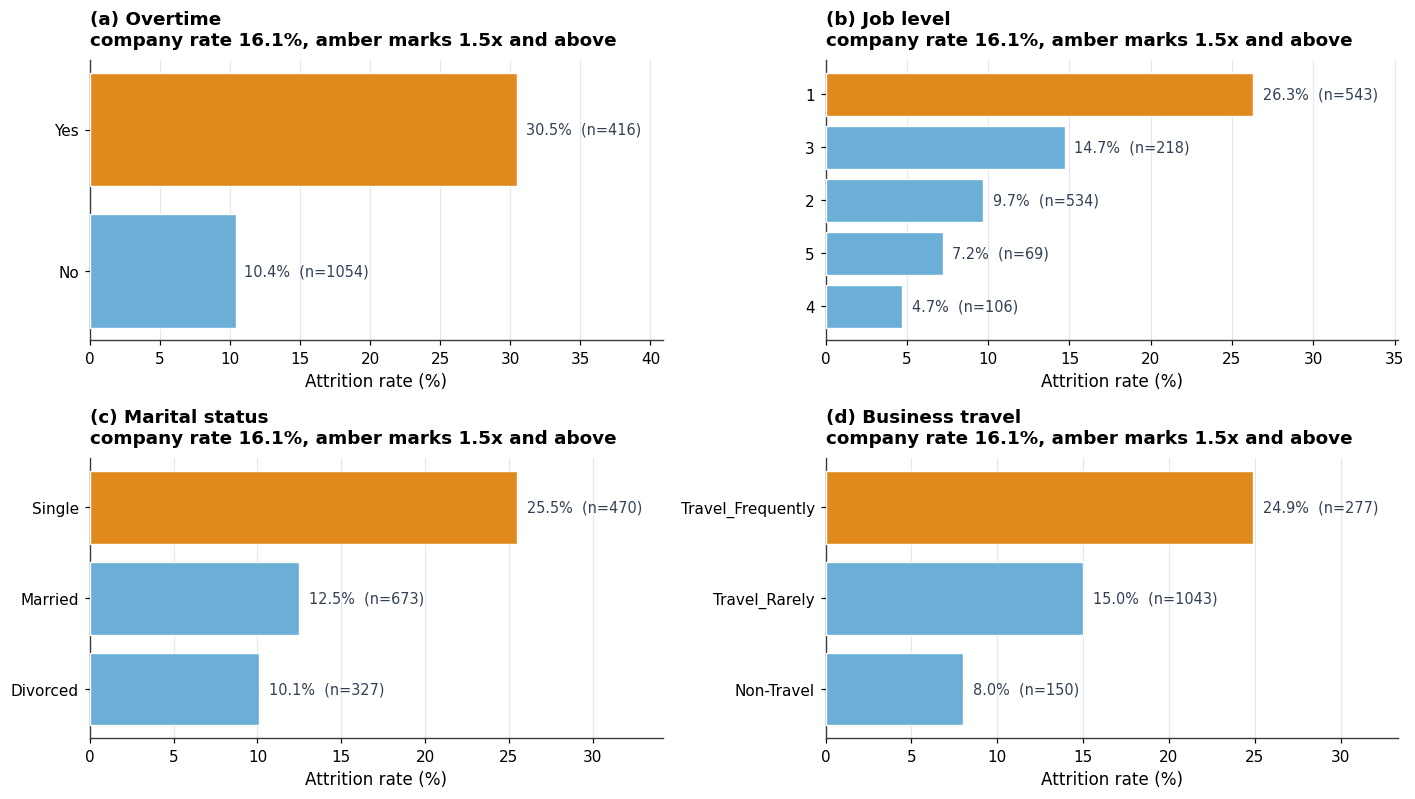

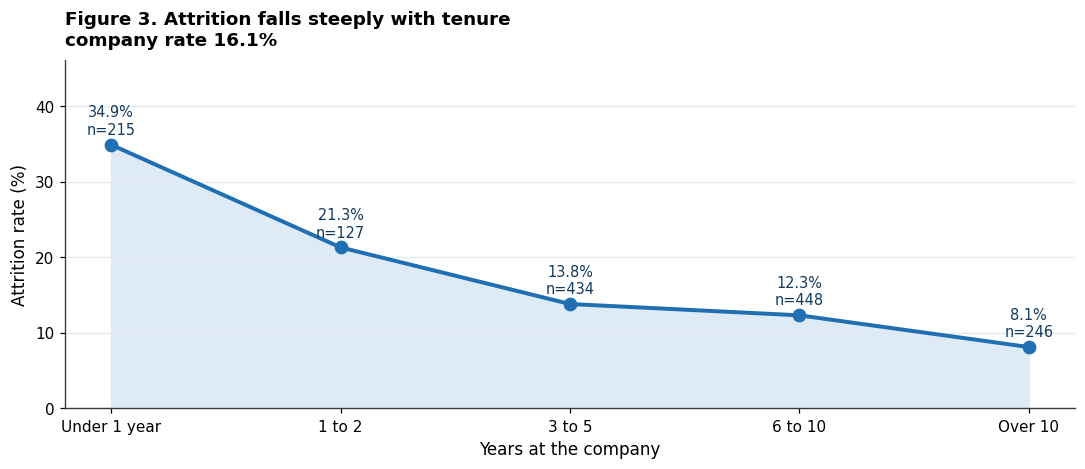

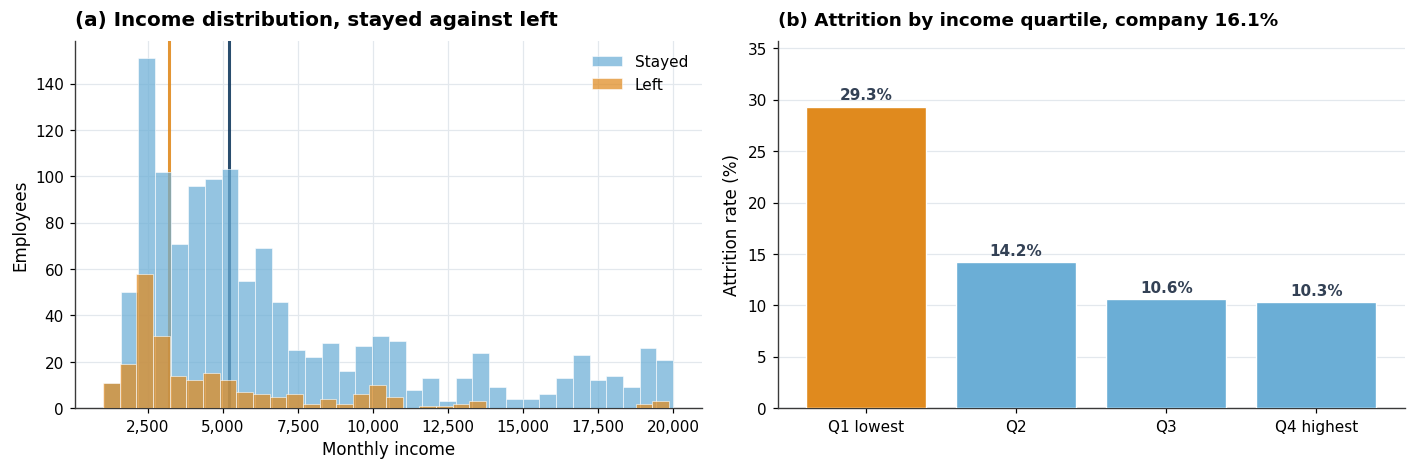

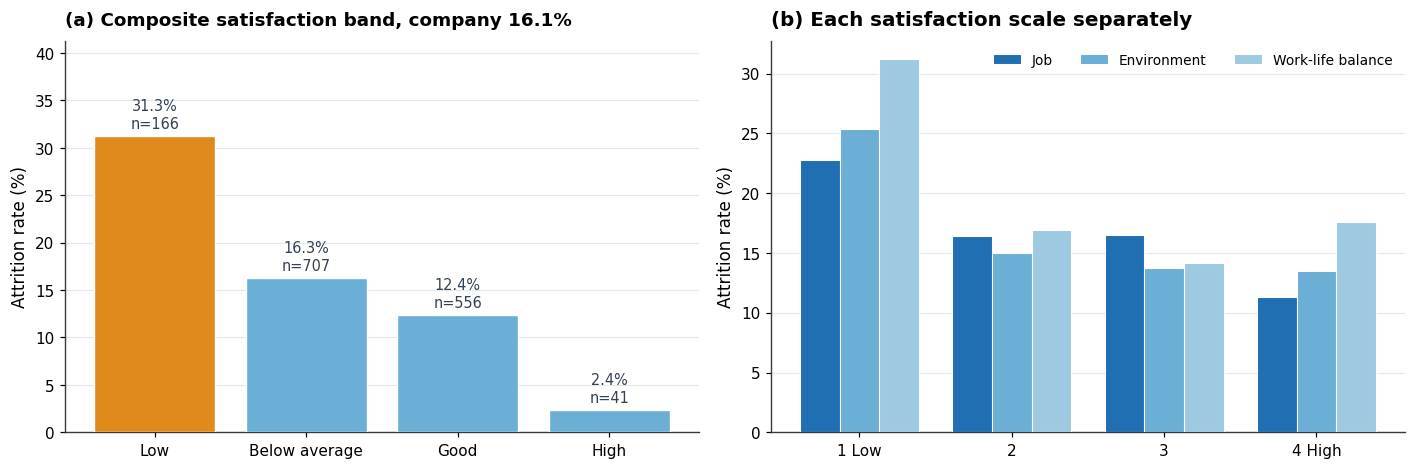

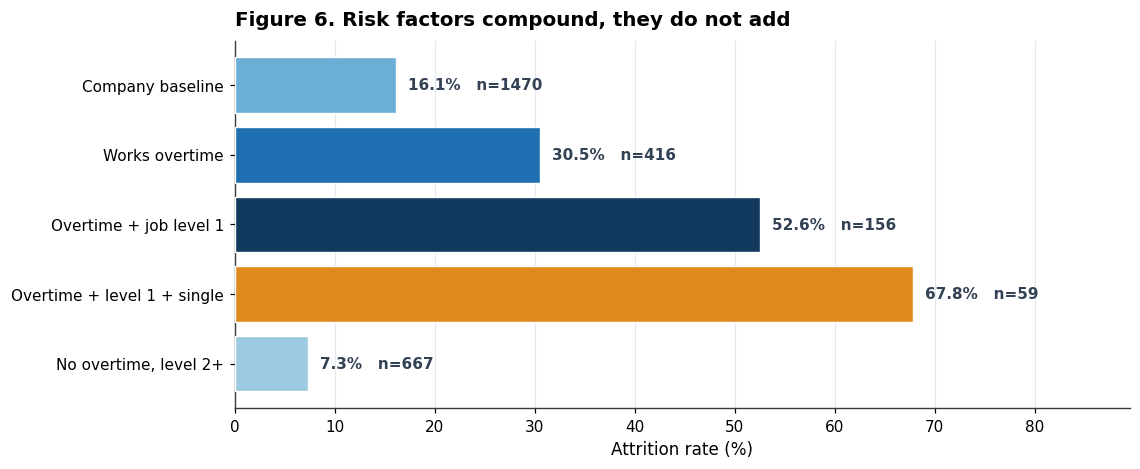


Charts written: ['01_attrition_by_role.png', '02_attrition_factors.png', '03_tenure_curve.png', '04_pay_and_attrition.png', '05_satisfaction.png', '06_compounding_risk.png']


In [9]:
# =============================================================================
# 6. CHARTS
# -----------------------------------------------------------------------------
# INPUT  : the tables from section 5
# METHOD : the chart type follows the data type. Horizontal bars where the labels
#          are long, vertical bars where the categories are ordered, a line where
#          the x axis is a progression, and a waterfall where the point is that
#          risks compound.
# OUTPUT : six PNG files in charts/
# =============================================================================
def save(fig, name):
    """Write the figure AND display it, so the notebook shows the result."""
    fig.savefig(f"charts/{name}.png", bbox_inches="tight", dpi=180)
    plt.show()

def ratebar(ax, t, title, xlab="Attrition rate (%)"):
    """Horizontal attrition bars with the baseline drawn in, because a rate
    without its reference is not interpretable."""
    s = t.sort_values("attrition_pct")
    cols = [AMBER if v >= 100 * BASE * 1.5 else (BLUE if v >= 100 * BASE else MID)
            for v in s.attrition_pct]
    b = ax.barh(s.index.astype(str), s.attrition_pct, color=cols,
                edgecolor="white", linewidth=0.9, zorder=3)
    for bb, v, n in zip(b, s.attrition_pct, s.headcount):
        ax.text(v + 0.6, bb.get_y() + bb.get_height() / 2, f"{v:.1f}%  (n={n})",
                va="center", fontsize=9.5, color="#334155")
    ax.set_xlim(0, s.attrition_pct.max() * 1.34)
    ax.set_xlabel(xlab)
    # The reference sits in the subtitle and in the colour, not as a line across
    # the plot. Amber marks any segment at 1.5 times the company rate or above.
    ax.set_title(f"{title}\ncompany rate {100*BASE:.1f}%, amber marks 1.5x and above",
                 loc="left", fontsize=12)
    ax.grid(axis="y", alpha=0)

# Figure 1: who leaves, by job role
fig, ax = plt.subplots(figsize=(10, 4.6))
ratebar(ax, TABLES["JobRole"], "Figure 1. Attrition rate by job role")
plt.tight_layout(); save(fig, "01_attrition_by_role")

# Figure 2: the four strongest single factors, on one scale
fig, axes = plt.subplots(2, 2, figsize=(13, 7.4))
for ax, col, title in zip(axes.ravel(),
        ["OverTime", "JobLevel", "MaritalStatus", "BusinessTravel"],
        ["(a) Overtime", "(b) Job level", "(c) Marital status", "(d) Business travel"]):
    ratebar(ax, TABLES[col], title)
plt.tight_layout(); save(fig, "02_attrition_factors")

# Figure 3: tenure curve. A line, because tenure is a progression.
fig, ax = plt.subplots(figsize=(10, 4.4))
t = TABLES["tenure_band"].reindex(
    ["Under 1 year", "1 to 2", "3 to 5", "6 to 10", "Over 10"]).dropna()
ax.plot(t.index.astype(str), t.attrition_pct, "o-", color=BLUE, lw=2.6, ms=8, zorder=3)
ax.fill_between(range(len(t)), 0, t.attrition_pct, color=PALE, zorder=0)
for i, (v, n) in enumerate(zip(t.attrition_pct, t.headcount)):
    ax.text(i, v + 1.4, f"{v:.1f}%\nn={n}", ha="center", fontsize=9.5, color=NAVY)
ax.set_ylim(0, t.attrition_pct.max() * 1.32)
ax.set_xlabel("Years at the company"); ax.set_ylabel("Attrition rate (%)")
ax.set_title(f"Figure 3. Attrition falls steeply with tenure\ncompany rate {100*BASE:.1f}%".replace("{100*BASE:.1f}", f"{100*BASE:.1f}"), loc="left", fontsize=12)
ax.grid(axis="x", alpha=0)
plt.tight_layout(); save(fig, "03_tenure_curve")

# Figure 4: pay. Two panels, because the distribution and the rate say different
# things and neither alone is enough.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for lab, col, c in [("Stayed", 0, MID), ("Left", 1, AMBER)]:
    ax[0].hist(df.loc[df.attrition_flag == col, "MonthlyIncome"], bins=34,
               alpha=0.72, color=c, label=lab, edgecolor="white", linewidth=0.5, zorder=3)
# Median lines, drawn solid and thin so they read as annotation, not as a grid.
ax[0].axvline(F["median_income_left"], color=AMBER, lw=2.0, alpha=0.9)
ax[0].axvline(F["median_income_stayed"], color=NAVY, lw=2.0, alpha=0.9)
ax[0].set_xlabel("Monthly income"); ax[0].set_ylabel("Employees")
ax[0].set_title("(a) Income distribution, stayed against left", loc="left")
ax[0].legend(); ax[0].xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
q = TABLES["income_quartile"].reindex(["Q1 lowest", "Q2", "Q3", "Q4 highest"]).dropna()
cols = [AMBER if v >= 100 * BASE * 1.5 else MID for v in q.attrition_pct]
b = ax[1].bar(q.index.astype(str), q.attrition_pct, color=cols,
              edgecolor="white", linewidth=0.9, zorder=3)
for bb, v in zip(b, q.attrition_pct):
    ax[1].text(bb.get_x() + bb.get_width() / 2, v + 0.7, f"{v:.1f}%",
               ha="center", fontsize=10, fontweight="bold", color="#334155")
ax[1].set_ylim(0, q.attrition_pct.max() * 1.22)
ax[1].set_ylabel("Attrition rate (%)")
ax[1].set_title(f"(b) Attrition by income quartile, company {100*BASE:.1f}%", loc="left", fontsize=12)
ax[1].grid(axis="x", alpha=0)
plt.tight_layout(); save(fig, "04_pay_and_attrition")

# Figure 5: satisfaction. The composite band plus the individual scales.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
s = TABLES["satisfaction_band"].reindex(
    ["Low", "Below average", "Good", "High"]).dropna()
cols = [AMBER if v >= 100 * BASE * 1.5 else MID for v in s.attrition_pct]
b = ax[0].bar(s.index.astype(str), s.attrition_pct, color=cols,
              edgecolor="white", linewidth=0.9, zorder=3)
for bb, v, n in zip(b, s.attrition_pct, s.headcount):
    ax[0].text(bb.get_x() + bb.get_width() / 2, v + 0.8, f"{v:.1f}%\nn={n}",
               ha="center", fontsize=9.5, color="#334155")
ax[0].set_ylim(0, s.attrition_pct.max() * 1.32)
ax[0].set_ylabel("Attrition rate (%)")
ax[0].set_title(f"(a) Composite satisfaction band, company {100*BASE:.1f}%", loc="left", fontsize=12); ax[0].grid(axis="x", alpha=0)
w = 0.26
scales = [("JobSatisfaction_label", BLUE, "Job"),
          ("EnvironmentSatisfaction_label", MID, "Environment"),
          ("WorkLifeBalance_label", LIGHT, "Work-life balance")]
lv = ["1", "2", "3", "4"]
for i, (col, c, lab) in enumerate(scales):
    t2 = TABLES[col]
    vals = [t2[t2.index.astype(str).str.startswith(l)].attrition_pct.mean() for l in lv]
    ax[1].bar(np.arange(4) + (i - 1) * w, vals, w, color=c, label=lab,
              edgecolor="white", linewidth=0.7, zorder=3)
ax[1].set_xticks(range(4)); ax[1].set_xticklabels(["1 Low", "2", "3", "4 High"])
ax[1].set_ylabel("Attrition rate (%)"); ax[1].legend(ncol=3, fontsize=9)
ax[1].set_title("(b) Each satisfaction scale separately", loc="left")
ax[1].grid(axis="x", alpha=0)
plt.tight_layout(); save(fig, "05_satisfaction")

# Figure 6: the compounding effect, the operational centrepiece.
fig, ax = plt.subplots(figsize=(10.5, 4.4))
groups = [
    ("Company baseline", 100 * BASE, len(df), MID),
    ("Works overtime", F["overtime_rate"], int((df.OverTime == "Yes").sum()), BLUE),
    ("Overtime + job level 1",
     100 * df.loc[(df.OverTime == "Yes") & (df.JobLevel == 1), "attrition_flag"].mean(),
     int(((df.OverTime == "Yes") & (df.JobLevel == 1)).sum()), NAVY),
    ("Overtime + level 1 + single", F["risk_rate"], F["risk_n"], AMBER),
    ("No overtime, level 2+", F["safe_rate"], F["safe_n"], LIGHT),
]
labs = [g[0] for g in groups][::-1]
vals = [g[1] for g in groups][::-1]
ns   = [g[2] for g in groups][::-1]
cols = [g[3] for g in groups][::-1]
b = ax.barh(labs, vals, color=cols, edgecolor="white", linewidth=0.9, zorder=3)
for bb, v, n in zip(b, vals, ns):
    ax.text(v + 1.2, bb.get_y() + bb.get_height() / 2,
            f"{v:.1f}%   n={n}", va="center", fontsize=10,
            fontweight="bold", color="#334155")
ax.set_xlim(0, max(vals) * 1.32)
ax.set_xlabel("Attrition rate (%)")
ax.set_title("Figure 6. Risk factors compound, they do not add", loc="left")
ax.grid(axis="y", alpha=0)
plt.tight_layout(); save(fig, "06_compounding_risk")

json.dump(F, open("results/findings.json", "w"), indent=2, default=str)
print("\nCharts written:", sorted(os.listdir("charts")))

<a id="insights"></a>
# 13. Insights and recommendations

### 1. Overtime is the strongest single predictor, and it is a management choice

Employees working overtime leave at **30.5%**, those who do not at **10.4%**. That
is the largest difference produced by any single field.

What matters more than the size is its nature. Age, marital status and job level are
attributes of the employee. Overtime is an **outcome of how work is allocated**,
which makes it the one strong factor the company directly controls.

**Recommendation.** Audit overtime by manager and by role before touching pay or
benefits. The 28.3% of staff currently on overtime contain a disproportionate share
of next year's departures, and the lever is already in the company's hands.

### 2. Risk factors compound, they do not add

| Group | Headcount | Attrition |
| :--- | ---: | ---: |
| Company baseline | 1,470 | 16.1% |
| Works overtime | 416 | 30.5% |
| Overtime and job level 1 | 156 | 52.6% |
| **Overtime, level 1 and single** | **59** | **67.8%** |
| No overtime, level 2 and above | 667 | 7.3% |

**Recommendation.** Stop treating attrition as a company-wide average. Target the 59
identified individuals rather than launching a general engagement programme, which
spends most of its budget on the 667 people leaving at 7.3%.

### 3. The first two years carry nearly half the departures

Employees with two years or less are **23.3% of the workforce** and **43.0% of all
departures**. In the first year alone the rate reaches **34.9%**.

**Recommendation.** Move retention spending into the first 24 months: structured
onboarding, an assigned mentor, and a review at month 6 and month 18. An
intervention at year five reaches a population already leaving at half the company
rate.

### 4. Pay is a floor, not a ladder

Median income among leavers is **3,202** against **5,204** among those who stay. But
the effect is not linear: the lowest quartile leaves at **29.3%**, while the other
three sit between 10.3% and 14.2% and barely differ.

**Recommendation.** Review the lowest quartile against the local market. Do not fund
a general pay rise; it would change almost nothing above the first quartile.

### 5. Satisfaction matters, and performance cannot be measured

The lowest composite satisfaction band leaves at **31.3%** against **2.4%** in the
highest. **Work-life balance is the sharpest single scale**, and it connects
directly to the overtime finding: they are likely the same problem.

Against this, `PerformanceRating` contains only the values 3 and 4 and correlates
with income at -0.017. It cannot separate a strong performer from a weak one.

**Recommendation.** Act on work-life balance, and rebuild the appraisal process. A
scale on which nobody scores below 3 is not measuring performance.

<a id="limits"></a>
# 14. Limitations

**The data is synthetic.** IBM generated it to demonstrate attrition analysis. The
relationships are plausible and were designed, so every finding here should be
treated as a method demonstration until it is reproduced on the company's own
records.

**No leaving date.** `Attrition` is a flag with no date, so no trend over time can be
computed and a resignation cannot be separated from a dismissal. Every rate is a
snapshot.

**No manager identifier.** The overtime finding points at how work is allocated but
cannot say by whom. Adding a manager key would make Insight 1 actionable at team
level, and it is the single most valuable field to add.

**No performance measure**, as established in Section 8.

**Correlation, not causation.** That overtime accompanies departure does not prove it
causes it, though the mechanism is plausible and the effect is large. Testing it
requires a controlled change, not more analysis of this file.

#### Cell 10. Download the outputs

| | |
| :--- | :--- |
| **Input** | The files written above. |
| **Method** | Zips the charts and the tables, then triggers a browser download of the clean dataset and both archives. |
| **Output** | Three downloads on your machine. |

This cell makes the notebook usable end to end in Colab: without it the outputs stay in a session that disappears when the tab closes.


In [10]:
# --- Download the outputs (Colab only) ---------------------------------------
# INPUT  : the files written by the cells above
# METHOD : zips the charts and the tables, then triggers a browser download
# OUTPUT : three files on your machine
import shutil, sys
if "google.colab" in sys.modules:
    shutil.make_archive("Task3_charts", "zip", ".", "charts")
    shutil.make_archive("Task3_results", "zip", ".", "results")
    from google.colab import files
    files.download("data/HR_Attrition_clean.csv")
    files.download("Task3_charts.zip")
    files.download("Task3_results.zip")
    print("Three downloads triggered: the clean dataset, the charts, the tables.")
else:
    print("Not running in Colab. The outputs are on disk in data/, charts/ and results/.")

Not running in Colab. The outputs are on disk in data/, charts/ and results/.


<a id="refs"></a>
# 15. References

- Gebru, T., et al. (2021). Datasheets for datasets. *Communications of the ACM*, 64(12), 86-92. https://doi.org/10.1145/3458723
- IBM (2017). *HR Analytics Employee Attrition and Performance* [Data set]. Kaggle. https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly. https://wesmckinney.com/book/
- Stevens, S. S. (1946). On the theory of scales of measurement. *Science*, 103(2684), 677-680. https://doi.org/10.1126/science.103.2684.677
- Cascio, W. F., & Boudreau, J. W. (2011). *Investing in People*. Pearson.

## Companion deliverables

`dashboard.html` for the interactive dashboard, `POWERBI_GUIDE.md` and
`data/PowerBI_import.csv` to build the Power BI version, `DATA_QUALITY.md` for the
full audit, `INSIGHTS.md` for the conclusions, `report.pdf` for the formal document.

## Author

**KOUAME Koffi Fidèle** · koffifidelek59@gmail.com